# Data preprocessing 
This notebook contains the code to process the E18 stage scRNA+ATAC mouse embryonic brain dataset. The dataset is available through 10x (https://www.10xgenomics.com/datasets/fresh-embryonic-e-18-mouse-brain-5-k-1-standard-1-0-0).

Here we re-process this dataset. As a result, we write out adata_rna, adata_atac and adata_atac_raw anndata objects into the processed_data/ folder. adata_rna is used for all analyses; adata_atac is used for MultiVelo analyses; adata_atac_raw is used for ArchVelo analyses.

The input count matrix for the ArchVelo ATAC analysis (summit_counts_matrix.csv) and peaks-to-genes map (nearest_genes_summits_correct_annot.csv) can be downloaded at https://doi.org/10.6084/m9.figshare.27931914

Quantified unspliced and spliced counts from Velocyto and MultiVelo cell annotations can be found at the [MultiVelo GitHub page](https://github.com/welch-lab/MultiVelo/tree/main/Examples/) and should be downloaded into the ./data/ folder.

Please note that MultiVelo and ArchVelo differ significantly in their ATAC modality preprocessing pipeline. For MultiVelo analysis, please download the filtered_feature_bc_matrix, peak_annotation and feature_linkage files from the 10x website into the ./data/ folder.

Alternatively, the outputs can be downloaded at the same figshare link and this notebook can be omitted.

In [1]:
import os
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import multivelo as mv

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
scv.settings.verbosity = 3
scv.settings.presenter_view = True
scv.set_figure_params('scvelo')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
np.set_printoptions(suppress=True)

# Preprocessing

## ATAC

In [4]:
# read
adata_atac_raw = sc.read_csv('data/outs/our_peaks/summit_counts_matrix.csv').T


In [5]:
# filter
adata_atac_raw_full = adata_atac_raw.copy()
adata_atac_raw.layers['raw_counts'] = adata_atac_raw.X.copy()
sc.pp.filter_genes(adata_atac_raw, min_cells=0.01*adata_atac_raw.shape[0])
adata_atac_raw.layers['poisson_corrected'] = np.ceil(adata_atac_raw.layers['raw_counts']/2)

In [6]:
adata_atac_raw.shape

(4423, 175482)

In [7]:
# normalize
adata_atac_raw.X = np.array(adata_atac_raw.layers["poisson_corrected"].copy())
sc.experimental.pp.normalize_pearson_residuals(adata_atac_raw, theta=1)
adata_atac_raw.layers["pearson"] = adata_atac_raw.X.copy()

In [8]:
adata_atac_raw.shape

(4423, 175482)

## RNA

## preprocessing

In [9]:
adata_rna = scv.read('data/10X_multiome_mouse_brain.loom', cache=True)
adata_rna.obs_names = [x.split(':')[1][:-1] + '-1' for x in adata_rna.obs_names]
adata_rna.var_names_make_unique()

In [10]:
sc.pp.filter_cells(adata_rna, min_counts=1000)
sc.pp.filter_cells(adata_rna, max_counts=20000)

In [11]:
# Load previous cell annotations and subset to MultiVelo clusters
cell_annot = pd.read_csv('data/cell_annotations.tsv', sep='\t', index_col=0)

In [12]:
cell_annot['celltype'].unique()

array(['RG, Astro, OPC', 'Subplate', 'IPC', 'Ependymal cells',
       'Upper Layer', 'Interneurons2', 'V-SVZ', 'Deeper Layer',
       'Interneurons3', 'Cajal-Retzius', 'Interneurons1', 'Microglia'],
      dtype=object)

In [13]:
adata_rna = adata_rna[cell_annot.index,:]
adata_rna.obs['celltype'] = cell_annot['celltype']
adata_rna = adata_rna[adata_rna.obs['celltype'].isin(['RG, Astro, OPC', 
                                                      'IPC', 
                                                      'V-SVZ', 
                                                      'Upper Layer', 
                                                      'Deeper Layer', 
                                                      'Ependymal cells', 
                                                      'Subplate'])]


In [14]:
before_normalization = adata_rna.copy()

In [15]:
#for later visualization only
full_rna = before_normalization.copy()
scv.pp.filter_and_normalize(full_rna, min_counts = 0)
sc.tl.pca(full_rna, 30)
sc.pp.neighbors(full_rna, 50, n_pcs=30)
full_rna.layers['log1p'] = full_rna.X.copy()

Normalized count data: X, spliced, unspliced.
Logarithmized X.


/mnt/home/mavdeeva/Software/VENVs/arch-RR/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


In [16]:
full_rna.write('processed_data/full_rna.h5ad')

In [17]:
# Minimal filtering first
scv.pp.filter_and_normalize(adata_rna, min_shared_counts = 10)
sc.tl.pca(adata_rna, 30)
sc.pp.neighbors(adata_rna, 50, n_pcs=30)

Filtered out 21910 genes that are detected 10 counts (shared).
Normalized count data: X, spliced, unspliced.
Logarithmized X.


/mnt/home/mavdeeva/Software/VENVs/arch-RR/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


In [18]:
adata_rna.layers['log1p'] = adata_rna.X.copy()

/mnt/home/mavdeeva/Software/VENVs/arch-RR/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


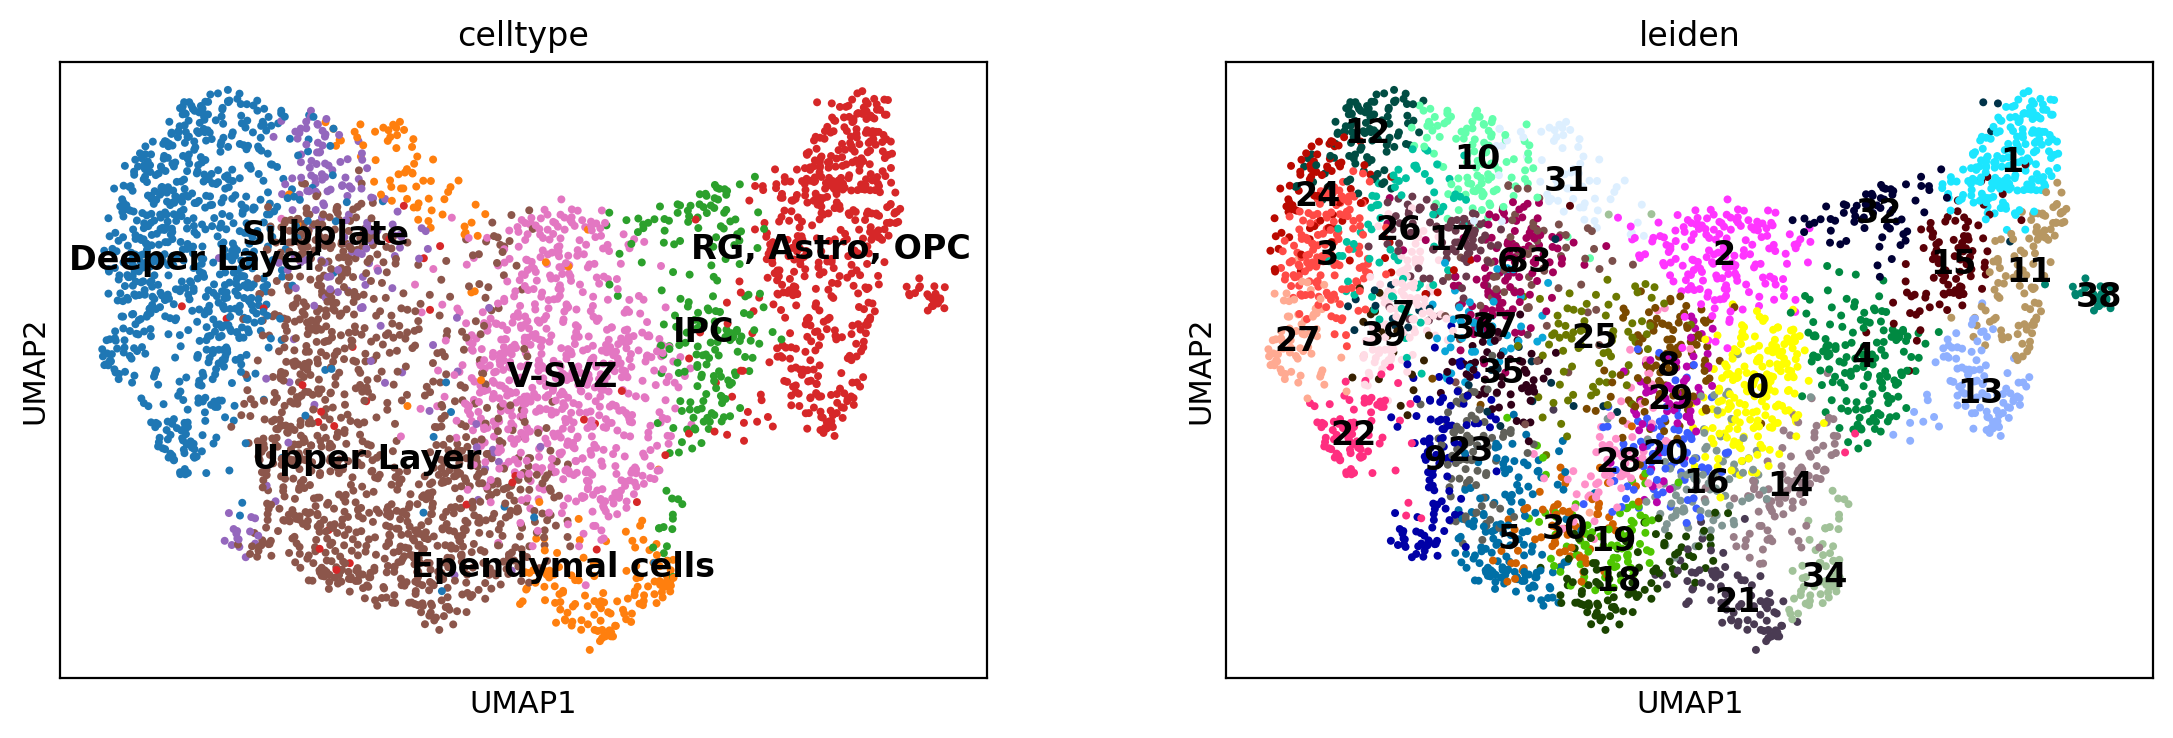

In [19]:
sc.tl.umap(adata_rna)
sc.tl.leiden(adata_rna, resolution=4)
sc.pl.umap(adata_rna, color = ['celltype', 'leiden'], legend_loc = 'on data')

In [20]:
sc.tl.rank_genes_groups(adata_rna, groupby = 'leiden',#reference = 'wt',
                        use_raw = False, method = 'wilcoxon', layer = 'log1p')
sc.tl.dendrogram(adata_rna, groupby = 'leiden')

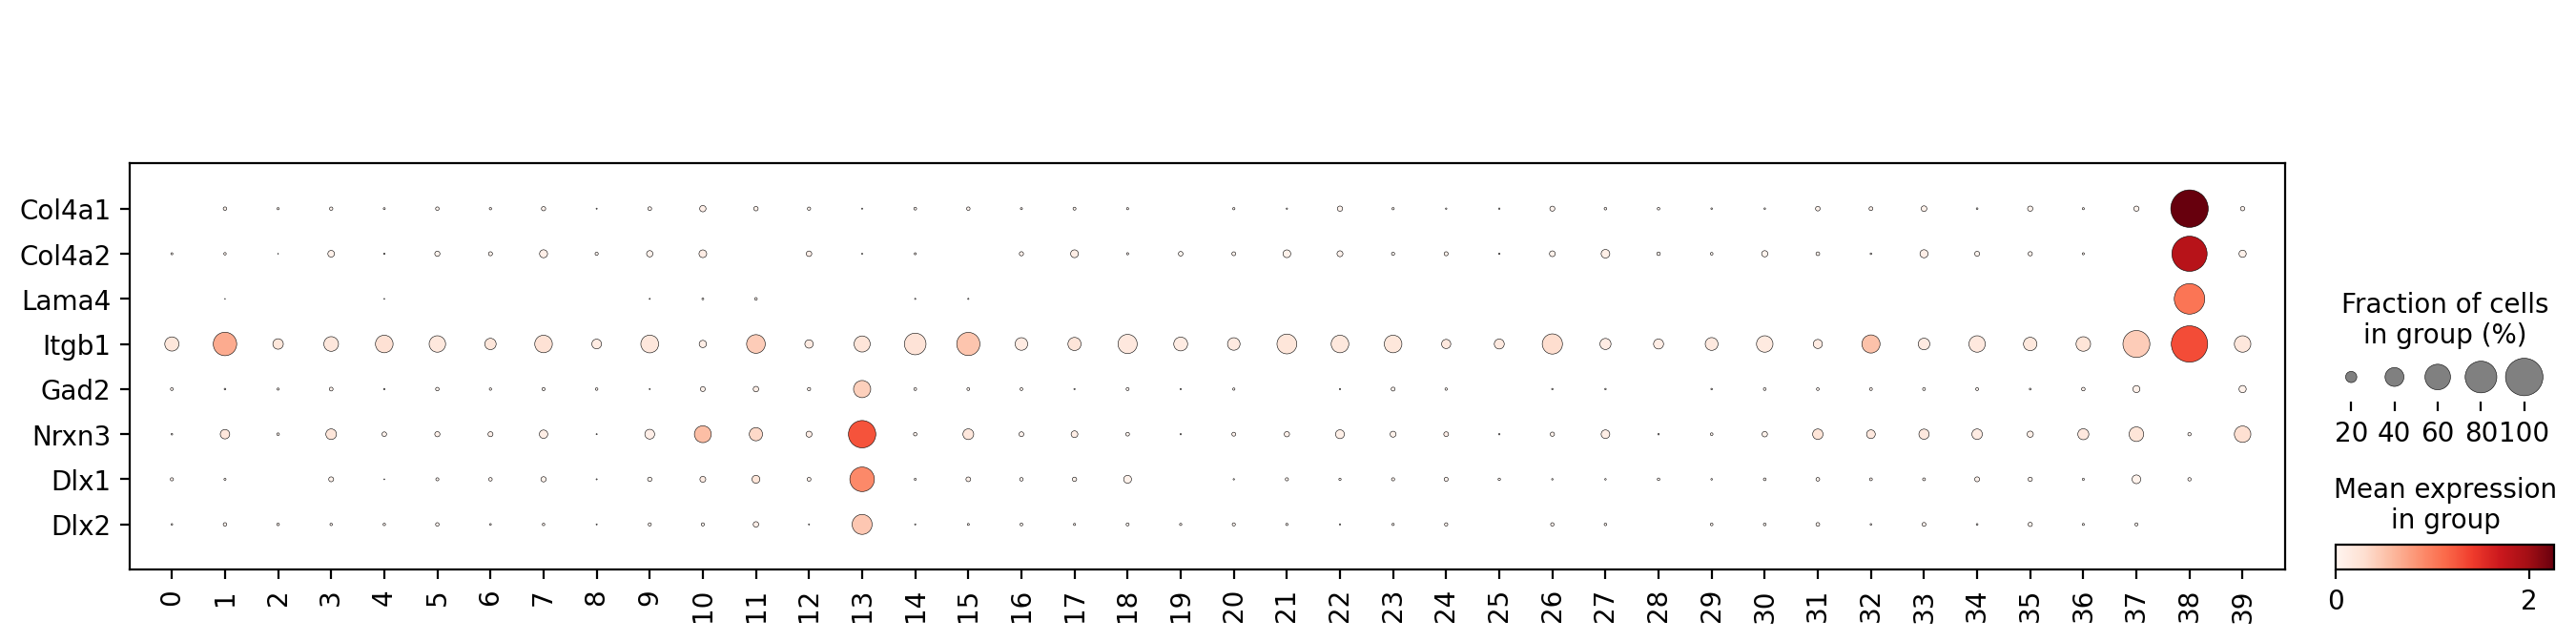

In [21]:
sc.pl.dotplot(adata_rna, 
              groupby = 'leiden',
              var_names = ['Col4a1','Col4a2', 'Lama4', 'Itgb1']+
                          ['Gad2', 'Nrxn3','Dlx1', 'Dlx2'], 
              swap_axes = True)

In [22]:
# remove vascular-associated and GABAergic
adata_rna = adata_rna[~adata_rna.obs['leiden'].isin(['13', '38']),:]
adata_rna.shape
new_cells = adata_rna.obs.index

In [23]:
adata_rna = before_normalization[new_cells,:].copy()

In [24]:
# filter again with highly variable
scv.pp.filter_and_normalize(adata_rna, min_shared_counts=10, n_top_genes=1000)

Filtered out 22210 genes that are detected 10 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 1000 highly variable genes.
Logarithmized X.


/mnt/home/mavdeeva/Software/VENVs/arch-RR/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


### subset peaks to ones that map to an RNA gene

In [25]:
peak_annotation = pd.read_csv('data/outs/our_peaks/nearest_genes_summits_correct_annot.csv', index_col = [0])

In [26]:
peak_annotation = peak_annotation.loc[adata_atac_raw.var_names,:]

In [27]:
#original ATAC matrix
adata_atac_raw.shape

(4423, 175482)

In [28]:
# leave only peaks that map to one of the genes in RNA matrix
rel_peaks = adata_atac_raw.var_names[peak_annotation['gene'].isin(adata_rna.var_names).values]

In [29]:
len(rel_peaks)

16477

In [30]:
# not all genes from RNA are present in the annotation
len(np.unique(peak_annotation.loc[rel_peaks]['gene']))

945

In [31]:
adata_atac_raw = adata_atac_raw[:, rel_peaks]

In [32]:
rel_genes = np.unique(peak_annotation[peak_annotation['gene'].isin(adata_rna.var_names).values]['gene'])

In [33]:
len(rel_genes)

945

## MultiVelo preprocessing

In [34]:
adata_atac = sc.read_10x_mtx('data/outs/filtered_feature_bc_matrix/', 
                             var_names='gene_symbols', cache=True, gex_only=False)
adata_atac = adata_atac[:,adata_atac.var['feature_types'] == "Peaks"]

In [35]:
# Aggregate peaks around each gene as well as those that have high correlations with promoter peak or gene expression.
# Peak annotation contains the metadata for all peaks.
# Feature linkage contains pairs of correlated genomic features.
adata_atac = mv.aggregate_peaks_10x(adata_atac, 
                                    'data/outs/peak_annotation.tsv', 
                                    'data/outs/analysis/feature_linkage/feature_linkage.bedpe', 
                                    verbose=True)

CellRanger ARC identified as 1.0.0
Found 19006 genes with promoter peaks


/mnt/home/mavdeeva/Software/VENVs/arch-RR/lib/python3.11/site-packages/ipywidgets/widgets/widget.py:503: DeprecationWarning: The `ipykernel.comm.Comm` class has been deprecated. Please use the `comm` module instead.For creating comms, use the function `from comm import create_comm`.
  self.comm = Comm(**args)


  0%|          | 0/19006 [00:00<?, ?it/s]

In [36]:
adata_atac.shape

(4881, 18993)

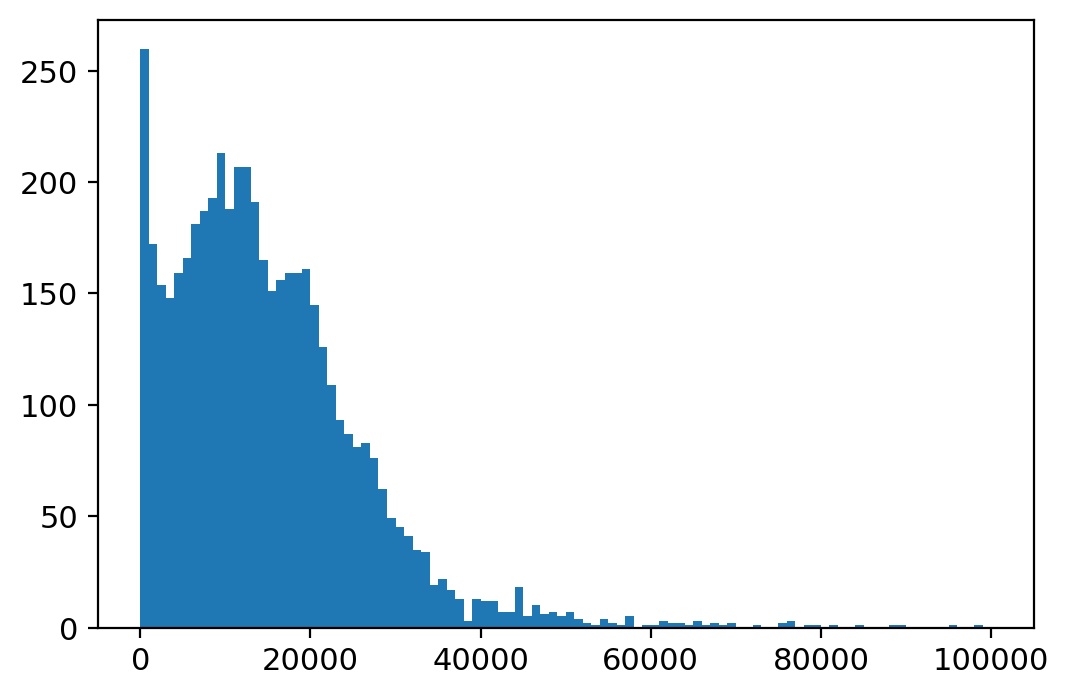

In [37]:
# Let's examine the total count distribution and remove outliers.
plt.hist(adata_atac.X.sum(1), bins=100, range=(0, 100000));

In [38]:
sc.pp.filter_cells(adata_atac, min_counts=2000)
sc.pp.filter_cells(adata_atac, max_counts=60000)

In [39]:
# We normalize aggregated peaks with TF-IDF.
mv.tfidf_norm(adata_atac)

In [40]:
adata_rna.shape, adata_atac.shape

((3526, 1000), (4414, 18993))

## Shared cells and features between RNA and ATAC

In [41]:
shared_cells = pd.Index(np.intersect1d(adata_rna.obs_names, adata_atac.obs_names))
shared_genes_atac = pd.Index(np.intersect1d(adata_rna.var_names, adata_atac.var_names))
shared_genes_atac_raw = pd.Index(np.intersect1d(adata_rna.var_names, rel_genes))
# print('# cells shared between processed RNA and multivelo filtered ATAC matrix: ',len(shared_cells))
# print('# genes shared between RNA var_names and multivelo aggregated ATAC var_names', len(shared_genes_atac))
# print('# genes shared between RNA var_names and the genes to which our ATAC peaks map', len(shared_genes_atac_raw))

In [42]:
#mapping somewhere
mapped_genes = np.unique(np.unique(peak_annotation['gene'].dropna()))
#present in rna
rna_genes = adata_rna.var_names
#present in adata_atac
aggr_genes = adata_atac.var_names
#present in adata_atac_raw
atac_raw_genes = np.unique(peak_annotation.loc[adata_atac_raw.var_names]['gene'])


In [43]:
shared_genes_total = mapped_genes
shared_genes_total = np.intersect1d(shared_genes_total, rna_genes)
shared_genes_total = np.intersect1d(shared_genes_total, aggr_genes)
shared_genes_total = np.intersect1d(shared_genes_total, atac_raw_genes)

In [44]:
print('# genes shared between both methods: ', len(shared_genes_total))

# genes shared between both methods:  930


In [45]:
#leave only corresponding peaks
rel_peaks_total = adata_atac_raw.var_names[peak_annotation.loc[adata_atac_raw.var_names,:]['gene'].isin(shared_genes_total).values]

In [46]:
len(rel_peaks_total)

16271

# Reload, subset and process

In [47]:
adata_rna_atac_total = adata_rna[shared_cells, shared_genes_total]
adata_atac_total = adata_atac[shared_cells, shared_genes_total]
adata_atac_raw_total = adata_atac_raw[shared_cells, rel_peaks_total]

In [48]:
adata_atac = adata_atac_total
adata_atac_raw = adata_atac_raw_total

In [49]:
adata_rna = adata_rna_atac_total.copy()

In [50]:
adata_rna.shape

(3252, 930)

In [51]:
n_pcs=30
n_neigh=50

In [52]:
sc.tl.pca(adata_rna, n_pcs)
sc.pp.neighbors(adata_rna, n_neigh, n_pcs=n_pcs)
scv.pp.moments(adata_rna, n_pcs=n_pcs, n_neighbors=n_neigh)

computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [53]:
adata_rna.layers['log1p'] = adata_rna.X.copy()

In [54]:
# scv.tl.umap(adata_rna)
# load umap for reproducibility
adata_rna.obsm['X_umap'] = pd.read_csv('processed_data/umap.csv', index_col = [0]).values

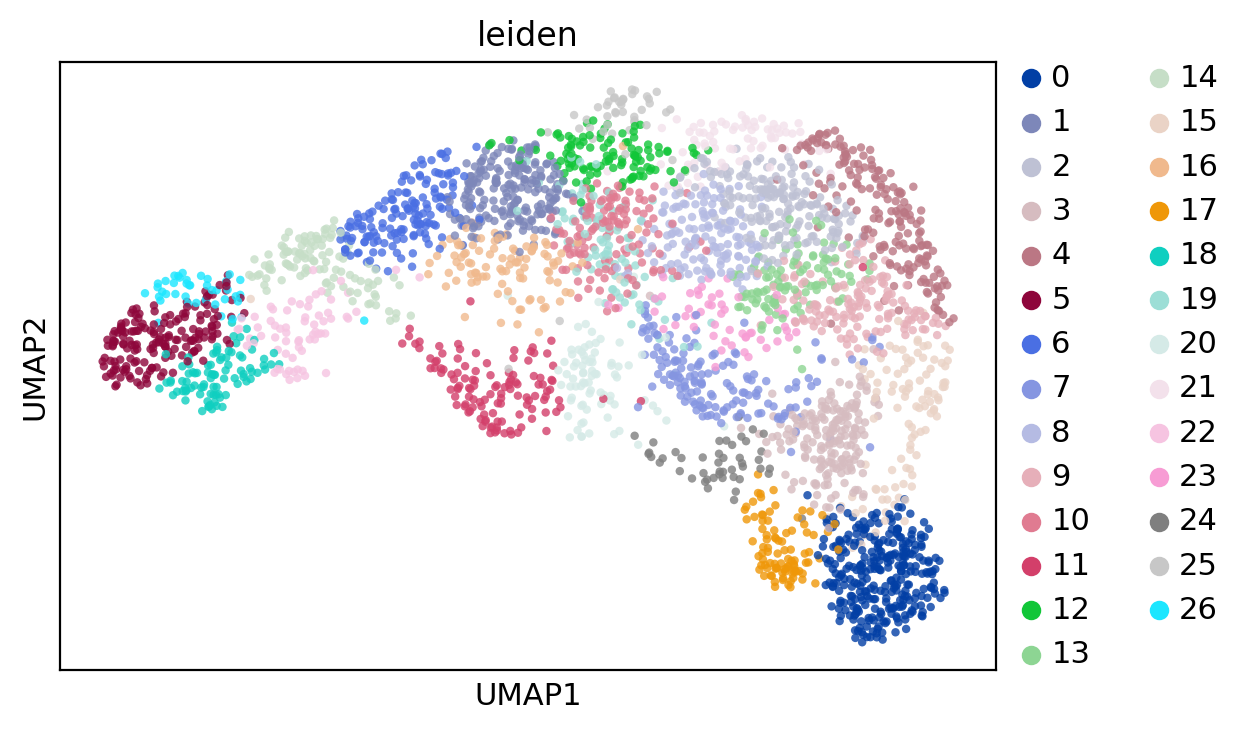

In [58]:
sc.tl.leiden(adata_rna, resolution=3.5)
sc.pl.umap(adata_rna, 
           color = ['leiden'], 
           alpha = 0.8)

In [60]:
#reannotate based on DE
map_new = {
              '14': 'IPC',
              '6':'IPC',
              '1':'MN1',
              '16':'MN1',
              '19':'MN1',
              '10':'MN1',
              '12':'MN1',
              '25':'MN1',
              '4': 'UL',
              '9': 'UL',
              '13': 'UL',
              '23': 'UL',
              '2': 'UL',
              '8': 'UL',
              '21': 'UL',
              '7': 'MN2',
              '11': 'MN2',
              '20': 'MN2',
              '24': 'MN2',
              '17': 'DL',
              '0': 'DL',
              '3': 'DL',
              '15': 'DL',              
              '26': 'AP',
              '5': 'A',
              '18': 'AC',
              '22': 'C',}

In [62]:
adata_rna.obs['cell_type_new'] = adata_rna.obs['leiden'].map({str(k): map_new[str(k)] for k in range(27)})

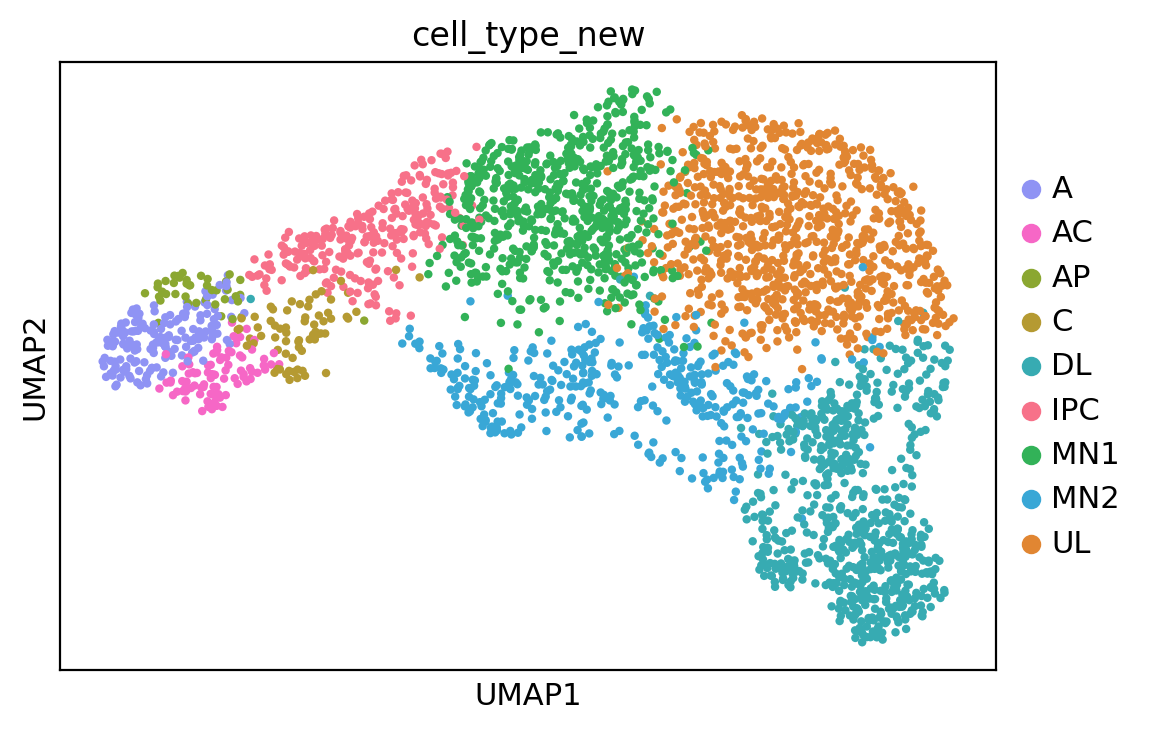

In [65]:
np.random.seed(57)
pal = sns.color_palette('husl', 11)
pal = list(np.array(pal)[[-3, -5, 2, -1, 3, 0,  4, -4, 1]])
sc.pl.umap(adata_rna, color = 'cell_type_new', palette = pal)

In [66]:
full_rna.layers['log1p'] = full_rna.X
full_rna = full_rna[adata_rna.obs.index,:]
full_rna.obs['cell_type_new'] = adata_rna.obs['cell_type_new']
full_rna.uns['cell_type_new_colors'] = adata_rna.uns['cell_type_new_colors']
full_rna.obsm['X_umap'] = adata_rna.obsm['X_umap']
full_rna.obs['leiden'] = adata_rna.obs['leiden']

In [67]:
# markers from Regev-Arlotta, Extended Data Figs. 2a and 4d
mark_dict = {'UL': ['Satb2', 'Cux1', 'Cux2', 'Plxna4', 
                   'Ptprk'],
             'DL': ['Fezf2', 'Bcl11b', 'Tle4',  'Sox5', 'Ldb2', 'Crym',  'Nr4a2', 'Tshz2', ],
             'M': ['Nrp1', ],
             'RG': [ 'Pax6', 'Hes5', 'Fabp7', 'Dbi', 'Slc1a3'],
'IPC': ['Eomes', 'Neurog2', 'Btg2'],
'A': ['Aldh1l1', 'Sparcl1',],
'OPC': ['Olig1', 'Olig2', 'Pdgfra'],
'N':['Neurod2', 'Neurod6', 'Tubb3'],

            }
# 

In [68]:
# added markers from Linnarsson Mouse Embryonic Brain Atlas and general cell cycle markers
mark_dict2 = {
'A': [ 'Slc6a11', 'Tnc', 'Slco1c1'],
'C':['Top2a', 'Mki67', 'Birc5', 'Tpx2'],
'M': ['Dcc', 'Sema3c', 'Unc5d'],
             }


In [69]:
for k in mark_dict2.keys():
    if k not in mark_dict.keys():
        mark_dict[k] = mark_dict2[k]
    else:
        mark_dict[k] += mark_dict2[k]

In [70]:
sns.set(context = 'notebook', style = 'ticks', font_scale = 1.5)
import matplotlib
matplotlib.rcParams['patch.edgecolor'] = 'black'
fig, ax = plt.subplots(1,1,dpi = 500, figsize = (13.5,5), )
sc.tl.dendrogram(full_rna, 'cell_type_new')
import matplotlib as mpl

g = sc.pl.dotplot(
    full_rna, 
    var_names={k:mark_dict[k] for k in ['UL', 'DL', 'M', 'C', 'A', 'RG', 'IPC', 'OPC', 'N']}, 
    groupby='cell_type_new', 
    dendrogram=True,
    standard_scale='var', 
    show=False,
    ax=ax 
)

# 1. Access the size legend axis
size_legend_ax = g['size_legend_ax']

# 2. Shrink the numbers (which are actually tick labels)
size_legend_ax.tick_params(axis='x', labelsize=8)

# 3. Shrink the title to match
size_legend_ax.title.set_fontsize(11)

color_legend_ax = g['color_legend_ax']
color_legend_ax.title.set_fontsize(12)              # Shrink the title
color_legend_ax.tick_params(labelsize=8)           # Shrink the colorbar numbers

fig.savefig('figures/Expression_of_markers_cell_type_new.png', dpi = 400)
fig.savefig('figures/Expression_of_markers_cell_type_new.svg', dpi = 400)

categories: A, AC, AP, etc.
var_group_labels: UL, DL, M, etc.


In [71]:
adata_rna.obs['cell_type_new'].to_csv('new_annot.csv')

In [72]:
adata_rna.obs['cell_type_abbr'] = adata_rna.obs['cell_type_new'].copy() #adata_rna.obs['leiden'].map(map_leiden)

In [76]:
adata_atac.obsm['X_umap'] = adata_rna.obsm['X_umap']
adata_atac_raw.obsm['X_umap'] = adata_rna.obsm['X_umap']

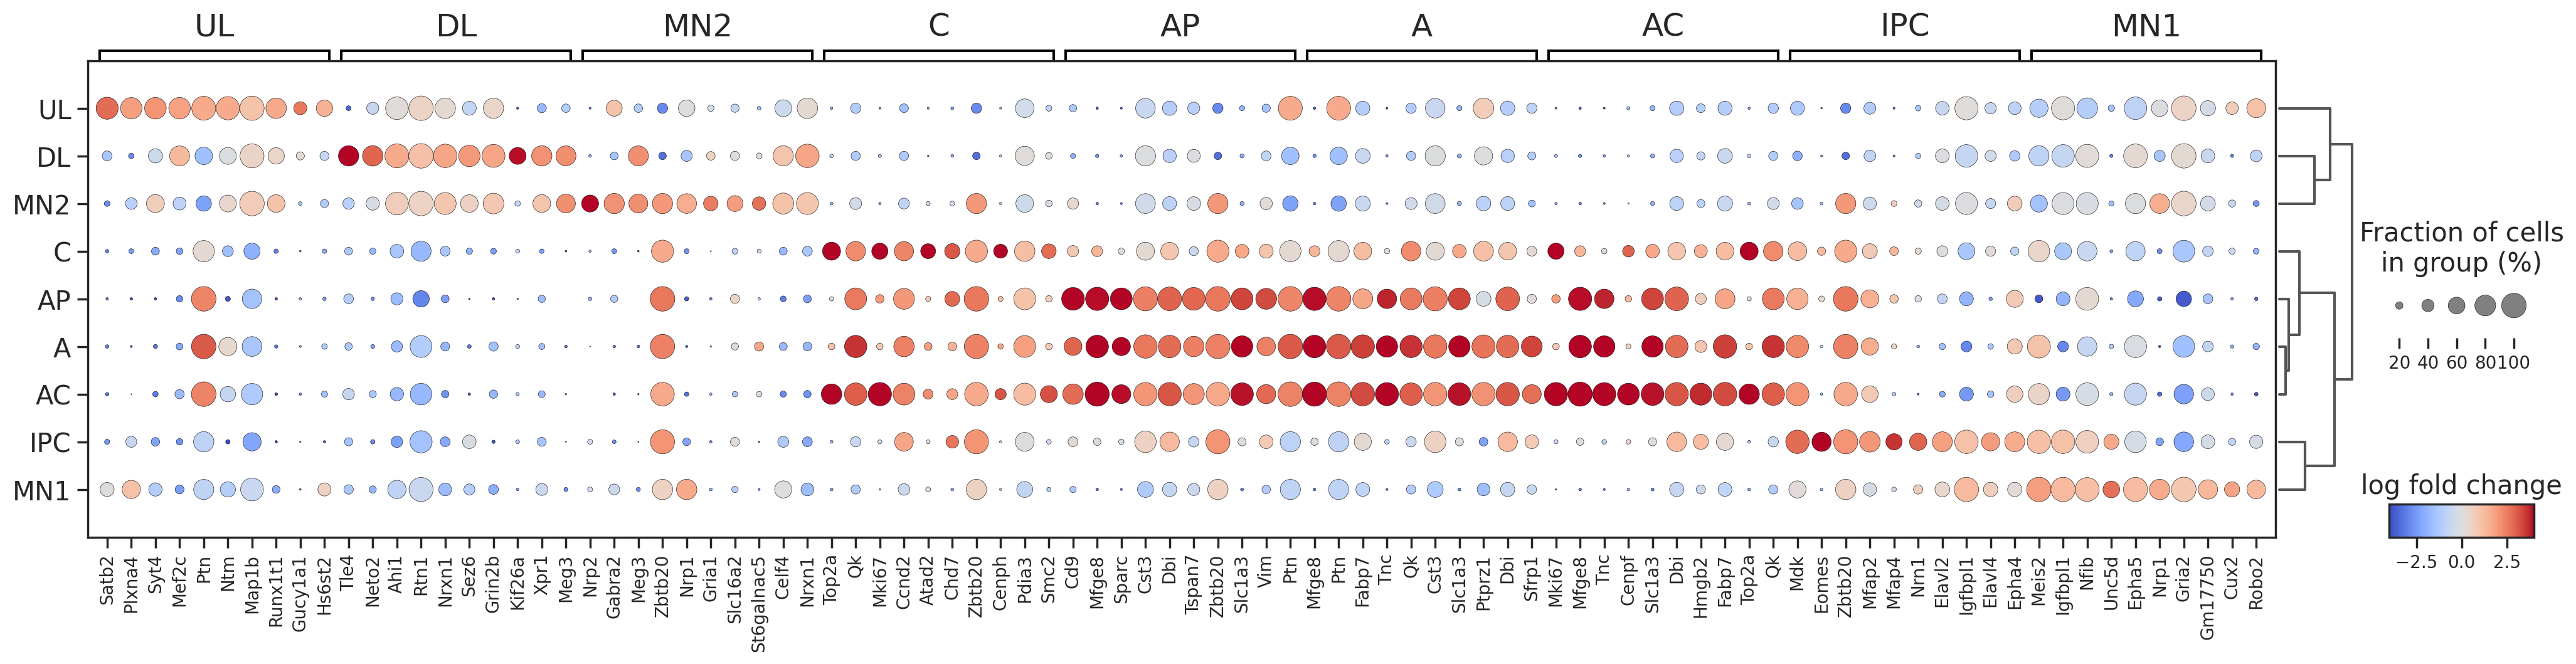

In [99]:
sc.tl.rank_genes_groups(adata_rna, groupby = 'cell_type_abbr',
                        use_raw = False, method = 'wilcoxon', layer = 'log1p')
sc.tl.dendrogram(adata_rna, groupby = 'cell_type_abbr')
g = sc.pl.rank_genes_groups_dotplot(adata_rna, 
                                values_to_plot = 'logfoldchanges', 
                                vmin = -4, vmax = 4,
                                cmap = 'coolwarm',
                                swap_axes = False,
                                n_genes = 10,
                                figsize = (25,5),
                                show = False,
                                return_fig = True)
g.make_figure()
axes_dict = g.get_axes()

main_ax = axes_dict['mainplot_ax']
main_ax.tick_params(axis='x', labelsize=10) # Change 8 to your desired font size

# --- 1. Size Legend Edits (Fraction of cells) ---
size_legend_ax = axes_dict['size_legend_ax']
# for text in size_legend_ax.texts:
#     text.set_fontsize(6)
size_legend_ax.tick_params(axis='both', labelsize=10) # Safety net

# --- 2. Color Legend Edits (Logfoldchanges) ---
color_legend_ax = axes_dict['color_legend_ax']
color_legend_ax.tick_params(axis='both', labelsize=10)
#plt.xticks(fontsize = 1)
plt.tight_layout()
g.fig.savefig('figures/DE_results_abbr.png', dpi = 500, bbox_inches='tight')
g.fig.savefig('figures/DE_results_abbr.svg', dpi = 500, bbox_inches='tight')

## Smoothing gene aggregated peaks by neighbors for MultiVelo

In [79]:
# Write out filtered cells and prepare to run Seurat WNN --> R script can be found on Github.
adata_rna.obs_names.to_frame().to_csv('filtered_cells.txt', header=False, index=False)

In [80]:
# Regenerate seurat_wnn
from multivelo.auxiliary import *
adata_rna.var['highly_variable'] = True
nn_idx, nn_dist = gen_wnn(adata_rna, adata_atac, [n_pcs,n_pcs], n_neigh)

Orig w/ prints v4
Computing KNN distance matrices using default Scanpy implementation
Adata:
AnnData object with n_obs × n_vars = 3252 × 930
    obs: 'n_counts', 'celltype', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'leiden', 'cell_type_old', 'cell_type_new', 'cell_type_abbr'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'log1p', 'pca', 'neighbors', 'celltype_colors', 'leiden', 'leiden_colors', 'cell_type_old_colors', 'cell_type_new_colors', 'cell_type_abbr_colors', 'rank_genes_groups', 'dendrogram_cell_type_abbr', '1', '2', '1_200', '2_200'
    obsm: 'X_umap', 'X_rna_pca', 'X_adt_lsi', 'X_rna_pca_norm', 'X_adt_lsi_norm'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'log1p'
    obsp: 'distances', 'connectivities', '1_distances', '1_connectivities', '2_distances', '2_connectivities', '1_200_distances', '1_200_connectiv

In [81]:
os.makedirs('seurat_wnn', exist_ok = True)

In [82]:
# Read in Seurat WNN neighbors.
np.savetxt('seurat_wnn/nn_idx.txt', nn_idx, delimiter=',')
np.savetxt('seurat_wnn/nn_dist.txt', nn_dist, delimiter=',')

In [83]:
mv.knn_smooth_chrom(adata_atac, nn_idx, nn_dist)

# Write out all data

In [85]:
adata_atac_raw.write('processed_data/adata_atac_raw.h5ad')

In [86]:
adata_atac.write('processed_data/adata_atac.h5ad')

In [87]:
adata_rna.write('processed_data/adata_rna.h5ad')